In [1]:
import h5py
import torch
class GalaxyDataset(torch.utils.data.Dataset):
    def __init__(self, path, limit=None):
    

        with h5py.File(path, "r") as f:
            images = f["images"][:limit] if limit else f["images"][:]
            labels = f["ans"][:limit] if limit else f["ans"][:]

        # Нормалізація
        self.images = torch.tensor(images, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)

        self.class_map = {
            0: 0, 1: 0,
            2: 1, 3: 1, 4: 1,
            5: 2, 6: 2, 7: 2,
            8: 3, 9: 3,
        }

        # Apply mapping
        self.labels = torch.tensor([self.class_map[int(y)] for y in self.labels])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx].permute(2, 0, 1)  # HWC -> CHW
        y = self.labels[idx]
        return x, y


In [2]:
import torch
import torch.nn as nn

class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=4, dropout_p=0.5):
        super(GalaxyCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 256 -> 128
            nn.Dropout(dropout_p),
            
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128 -> 64
            nn.Dropout(dropout_p),
            
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 -> 32
            nn.Dropout(dropout_p),
            
            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16
            nn.Dropout(dropout_p),
            
            # Block 5
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),  # Global pooling
            nn.Dropout(dropout_p)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(30),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

test_transforms = transforms.Compose([])  # no augmentation


In [ ]:
from torch.utils.data import random_split

dataset = GalaxyDataset("../data/Galaxy10_DECals.h5")  # transform applied later





In [58]:
test_ratio = 0.15
test_size = int(len(dataset) * test_ratio)
train_size = len(dataset) - test_size

In [59]:
test_size

2660

In [64]:
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Wrap subsets with transforms
from torch.utils.data import Dataset

class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.targets = torch.tensor([self.subset[i][1] for i in range(len(self.subset))], dtype=torch.long)

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label



In [65]:
train_dataset = TransformedSubset(train_dataset, transform=train_transforms)
test_dataset = TransformedSubset(test_dataset, transform=test_transforms)


In [66]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,        # ↑
    shuffle=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    pin_memory=True
)

In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm import tqdm

# -------------------------
# 1. Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# 2. Datasets
# -------------------------
# Припускаємо, що train_dataset та test_dataset вже готові
# train_dataset.targets повинні містити лейбли (0..3)
# test_dataset.targets — для evaluation

batch_size = 64

# -------------------------
# 3. WeightedRandomSampler
# -------------------------
labels = torch.tensor(train_dataset.targets)
class_sample_count = torch.tensor([(labels == i).sum() for i in range(4)], dtype=torch.float)
class_weights = 1. / class_sample_count
samples_weight = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

# -------------------------
# 4. Model
# -------------------------
model = GalaxyCNN(num_classes=4)
model = model.to(device)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

# -------------------------
# 5. Class weights & criterion
# -------------------------
class_counts = torch.tensor([
    1081 + 1853,                 # Irregular
    2645 + 2027 + 334,           # Smooth
    2043 + 1829 + 2628,          # Spiral
    1423 + 1873                  # Edge-on
], dtype=torch.float)

weights = class_counts.sum() / class_counts
weights = weights.to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=0.1
)

# -------------------------
# 6. Optimizer & Scheduler
# -------------------------
optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

# -------------------------
# 7. AMP scaler
# -------------------------
scaler = torch.cuda.amp.GradScaler()

C:\Users\Anya\AppData\Local\Temp\ipykernel_22200\2510370928.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(train_dataset.targets)
C:\Users\Anya\AppData\Local\Temp\ipykernel_22200\2510370928.py:93: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [71]:
# -------------------------
# 8. Training loop
# -------------------------
num_epochs = 50
best_val_acc = 0
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    train_loss, correct, total = 0, 0, 0

    for i, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            predicted = outputs.argmax(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # --- Scheduler step ---
    scheduler.step()  # CosineAnnealingLR

    # --- Save best model ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "../models/best_model.pth")

    # --- Save metrics ---
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
          f"Best Val Acc: {best_val_acc:.4f}")

Epoch 1:   0%|          | 0/236 [00:00<?, ?it/s]C:\Users\Anya\AppData\Local\Temp\ipykernel_22200\1066892187.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 236/236 [05:15<00:00,  1.34s/it]
C:\Users\Anya\AppData\Local\Temp\ipykernel_22200\1066892187.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/50 | Train Loss: 1.2726, Train Acc: 0.3293 | Val Loss: 1.8842, Val Acc: 0.2880 | Best Val Acc: 0.2880


Epoch 2: 100%|██████████| 236/236 [05:13<00:00,  1.33s/it]


Epoch 2/50 | Train Loss: 1.1166, Train Acc: 0.4609 | Val Loss: 1.8433, Val Acc: 0.2932 | Best Val Acc: 0.2932


Epoch 3: 100%|██████████| 236/236 [05:17<00:00,  1.35s/it]


...

Epoch 18/50 | Train Loss: 0.7191, Train Acc: 0.7866 | Val Loss: 0.8503, Val Acc: 0.7184 | Best Val Acc: 0.7226


Epoch 19: 100%|██████████| 236/236 [05:14<00:00,  1.33s/it]


Epoch 19/50 | Train Loss: 0.7217, Train Acc: 0.7842 | Val Loss: 0.8738, Val Acc: 0.7120 | Best Val Acc: 0.7226


Epoch 20:  50%|████▉     | 117/236 [02:38<02:41,  1.36s/it]


KeyboardInterrupt: 

In [ ]:
print(next(model.parameters()).device)


cuda:0


ValueError: x and y must have same first dimension, but have shapes (20,) and (19,)

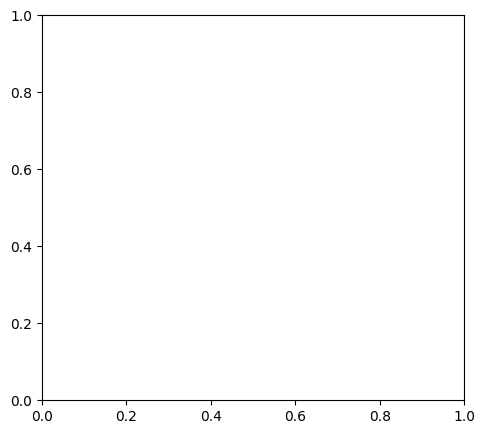

In [72]:
epochs = range(1, epoch+2)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'b-', label='Train Accuracy')
plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


Processed 0 images
Processed 1000 images
Processed 2000 images
Accuracy: 0.8925
           Irregular  Smooth  Spiral  Edge-on
Irregular        369      55      49        6
Smooth            13     677      18        6
Spiral            62      42     808       22
Edge-on            4       4       5      520


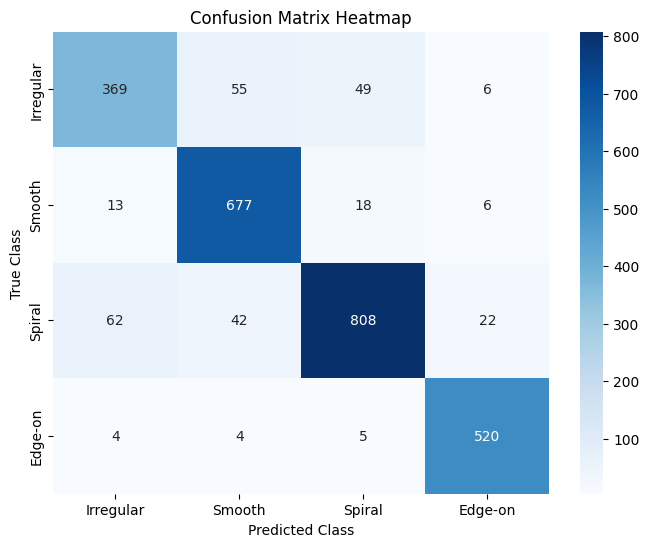

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torchmetrics.classification import MulticlassConfusionMatrix
from torchvision import transforms
from PIL import Image

# -------------------------
# 1. Налаштування
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 4

# -------------------------
# 2. Класи
# -------------------------
class_names = ["Irregular", "Smooth", "Spiral", "Edge-on"]

# -------------------------
# 3. Dataset і DataLoader
# -------------------------
# dataset має повертати (image_tensor, label, metadata)
# тут batch_size=1, бо робимо покрокові predictions
dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# -------------------------
# 4. Модель
# -------------------------
model.eval()  # переконайся що модель в eval()
model.to(device)

# -------------------------
# 5. Prediction loop
# -------------------------
correct = 0
predicted_labels = []
true_labels = []

for i, (image, label) in enumerate(dataloader):
    # Переносимо на GPU
    image = image.to(device, dtype=torch.float)
    label = label.to(device)

    # Batch dimension вже є (batch_size=1)
    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        true_idx = label.item()

    predicted_labels.append(pred_idx)
    true_labels.append(true_idx)

    if i % 1000 == 0:
        print(f"Processed {i} images")

    if pred_idx == true_idx:
        correct += 1

accuracy = correct / len(true_labels)
print(f"Accuracy: {accuracy:.4f}")

# -------------------------
# 6. Confusion Matrix
# -------------------------
pred_tensor = torch.tensor(predicted_labels)
true_tensor = torch.tensor(true_labels)

metric = MulticlassConfusionMatrix(num_classes=num_classes)
cm = metric(pred_tensor, true_tensor)

cm_df = pd.DataFrame(cm.numpy(), index=class_names, columns=class_names)
print(cm_df)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [148]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
from PIL import Image
import numpy as np
import requests
from io import BytesIO
import torchvision.transforms as transforms
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_sdss_image(ra, dec, size=256):
    """
    ra, dec — координати
    size — пікселі (256x256)
    """

    url = f"https://skyserver.sdss.org/dr16/SkyServerWS/ImgCutout/getjpeg?ra={ra}&dec={dec}&width={size}&height={size}&scale=0.1"

    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    return img


In [149]:
from PIL import Image
import torch
import numpy as np

def load_image_from_disk(path, size=256):
    img = Image.open(path).convert("RGB")

    # resize
    img = img.resize((size, size))

    # PIL -> numpy
    img = np.array(img).astype(np.float32) / 255.0

    # HWC -> CHW
    img = torch.from_numpy(img).permute(2, 0, 1)

    return img


In [150]:
def classify_local_image(path):
    x = load_image_from_disk(path)

    x = x.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)

        pred = probs.argmax(1).item()
        conf = probs.max().item()

    print("Predicted:", class_names[pred])
    print("Confidence:", round(conf, 4))

    return pred, conf


In [151]:
def classify_sdss(ra, dec):
    img = get_sdss_image(ra, dec, size=256)

    # PIL -> Tensor
    x = preprocess_pil(img)

    # add batch dim
    x = x.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)

        pred = probs.argmax(1).item()
        conf = probs.max().item()

    print("Predicted:", class_names[pred])
    print("Confidence:", round(conf, 4))

    return img, pred, conf



import torch
import numpy as np
from PIL import Image

def preprocess_pil(img, size=256):
    # resize
    img = img.resize((size, size))

    # PIL -> numpy
    img = np.array(img).astype(np.float32) / 255.0  # normalize 0–1

    # HWC -> CHW
    img = torch.from_numpy(img).permute(2, 0, 1)

    return img


Predicted: Smooth
Confidence: 0.337


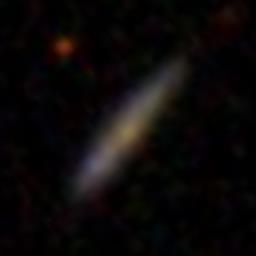

In [152]:
ra, dec = 231.09388, +43.03076
model = GalaxyCNN().to(device)
model.load_state_dict(torch.load("../models/best_model.pth", weights_only=True))

img, pred, conf = classify_sdss(ra, dec)
img


In [153]:
classify_local_image("images.jpg")

Predicted: Spiral
Confidence: 0.7899


(2, 0.7899061441421509)